# Normalization

In [45]:
import logging

import anndata
import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.sparse import issparse

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    # color_map="YlGnBu",
    frameon=False,
)

rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [46]:
adata = anndata.read_h5ad("../quality_control/quality_control.h5ad.gz")
adata

AnnData object with n_obs × n_vars = 3575 × 15040
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_versions', 'splicing', 'clean_ids', 'gene_symbol', 'new_ID', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'ambiguous', 'soupX_counts', 'spliced', 'unspliced'

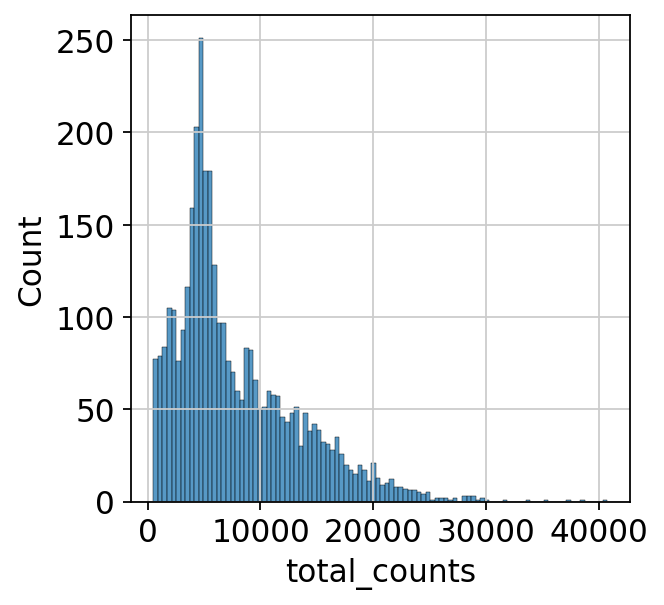

In [47]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

## Shifted Logarithm using Scanpy

In [48]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

## Seurat LogNormalize

In [49]:
%%R
library(Seurat)

In [50]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(adata)

In [51]:
%%R -i r_data -o sce_norm
r_data <- as(r_data, 'SingleCellExperiment')
print(r_data)
seu_data <- Seurat::as.Seurat(r_data,
                              counts="X",
                              data=NULL,
                              assay=NULL)
seu_norm <- NormalizeData(seu_data, normalization.method = "LogNormalize", scale.factor = 10000)
sce_norm <- Seurat::as.SingleCellExperiment(seu_norm)
print(sce_norm)

class: SingleCellExperiment 
dim: 15040 3575 
metadata(0):
assays(6): X ambiguous ... unspliced log1p_norm
rownames(15040): ENSG00000001461 ENSG00000010072 ... ENSG00000286009
  ENSG00000293305
rowData names(15): gene_versions splicing ... log1p_total_counts
  n_cells
colnames(3575): AGATTGCTCCCTCAGT_Hair_graft_4
  CTCGAAACATTCGACA_Hair_graft_4 ... GCTGCAGCAGCCAATT_Hair_graft_5
  CATTATCCAGCTCGCA_Hair_graft_5
colData names(19): sample n_genes_by_counts ... scDblFinder_score
  scDblFinder_class
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
class: SingleCellExperiment 
dim: 15040 3575 
metadata(0):
assays(2): counts logcounts
rownames(15040): ENSG00000001461 ENSG00000010072 ... ENSG00000286009
  ENSG00000293305
rowData names(0):
colnames(3575): AGATTGCTCCCTCAGT_Hair_graft_4
  CTCGAAACATTCGACA_Hair_graft_4 ... GCTGCAGCAGCCAATT_Hair_graft_5
  CATTATCCAGCTCGCA_Hair_graft_5
colData names(23): orig.ident nCount_originalexp ... scDblFinder_class
  ident
reducedDimNames(0):
mainExpName:

In [52]:
sce_norm

<rpy2.robjects.methods.RS4 object at 0x7fba0cd34dc0> [RTYPES.S4SXP]
R classes: ('SingleCellExperiment',)

In [53]:
with (ro.default_converter + anndata2ri.converter).context():
  norm = ro.conversion.get_conversion().rpy2py(sce_norm)

In [54]:
norm

AnnData object with n_obs × n_vars = 3575 × 15040
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'ident'
    layers: 'logcounts'

## Scran size factor estimation normalization

In [55]:
from scipy.sparse import csr_matrix

In [56]:
%%R
library(scran)
library(BiocParallel)

In [57]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

In [58]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()

In [59]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data_mat = ro.conversion.get_conversion().py2rpy(data_mat)
  r_data_groups = ro.conversion.get_conversion().py2rpy(adata_pp.obs["groups"])

In [60]:
del adata_pp

In [61]:
ro.globalenv["data_mat"] = r_data_mat
ro.globalenv["input_groups"] = r_data_groups

In [62]:
%%R -o size_factors
# compute the size factors based on the groups of cells we calculated before
size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [63]:
# save size_factors in .obs
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
adata.layers["scran_normalization"] = csr_matrix(sc.pp.log1p(scran))

## Normalized count distributions

In [64]:
import numpy as np
import pandas as pd
x = pd.DataFrame({'Scanpy':np.array(adata.layers["log1p_norm"].sum(1)).flatten(),
                 'Seurat':np.array(norm.layers["logcounts"].sum(1)).flatten(),
                 'Scran':np.array(adata.layers["scran_normalization"].sum(1)).flatten()})
x.describe()

,Scanpy,Seurat,Scran
count,3575.000000,3575.000000,3575.000000
mean,1902.070498,2534.932125,2145.758758
std,267.688734,414.343518,911.186178
min,881.508902,1056.410172,432.830719
25%,1805.147409,2379.156270,1544.648418
50%,1956.013229,2613.448525,1940.110033
75%,2064.250941,2786.964623,2756.576411
max,2675.697586,3744.864482,6217.604759


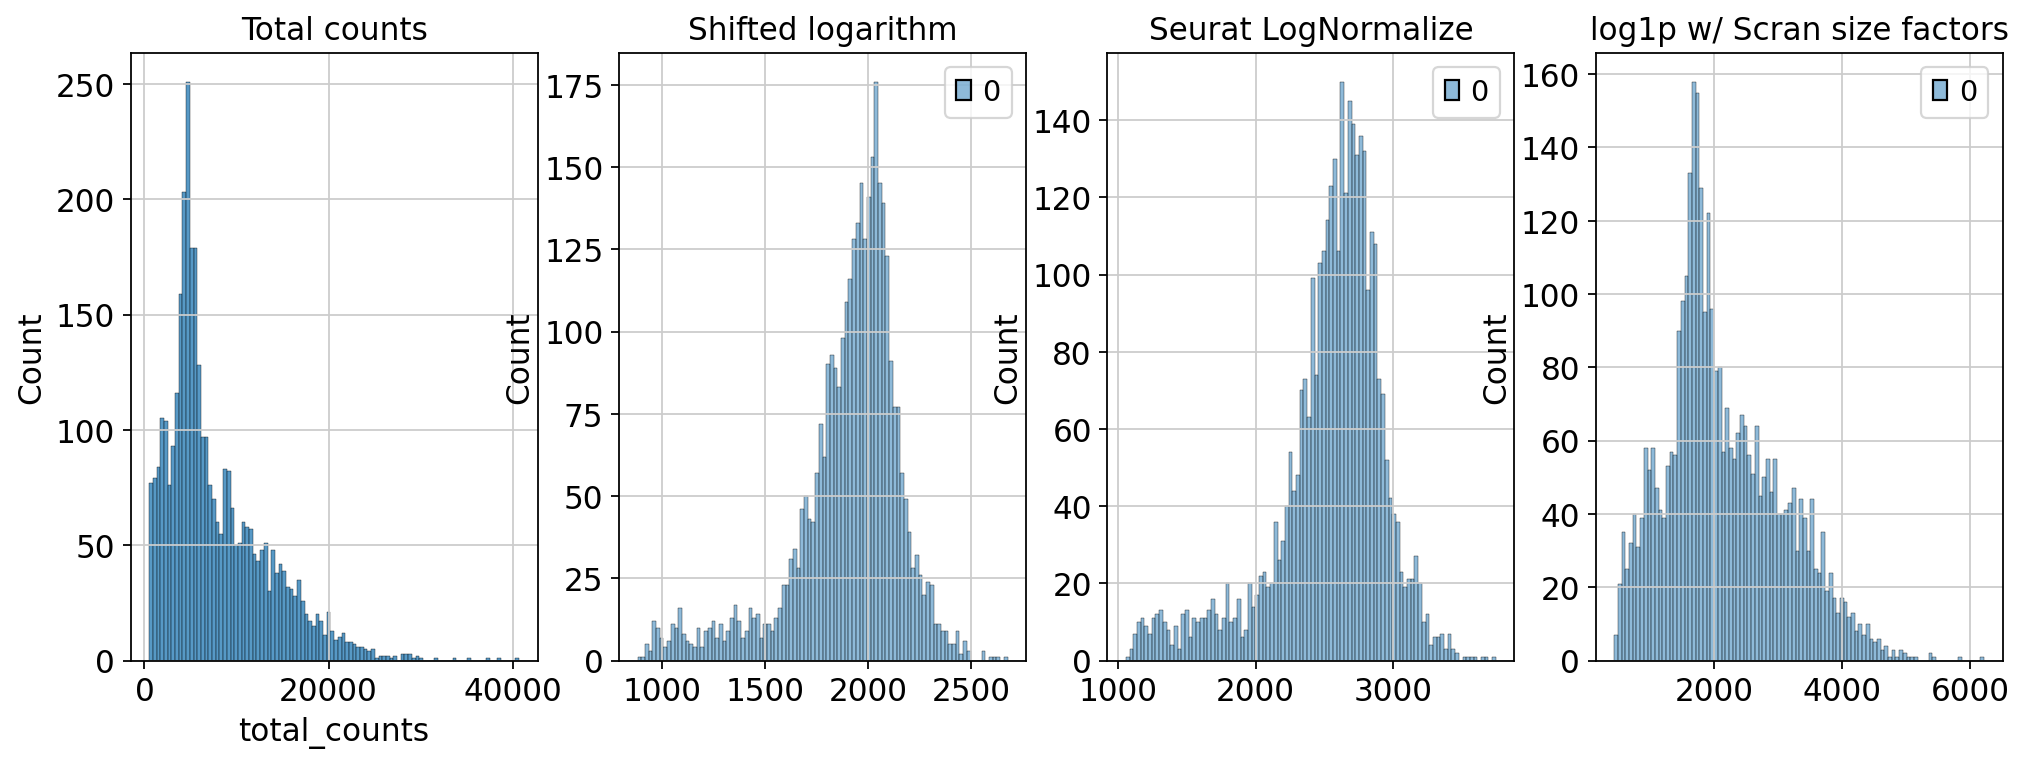

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
p3 = sns.histplot(norm.layers["logcounts"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("Seurat LogNormalize")
p4 = sns.histplot(adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[3])
axes[3].set_title("log1p w/ Scran size factors")
plt.show()

Scanpy shifted logarithm (sc.pp.normalize_total + sc.pp.log1p) and Seurat LogNormalize yield very similar distributions

In [66]:
# save the dataset to file
anndata.settings.allow_write_nullable_strings = True
adata.write("normalization.h5ad.gz", compression='gzip')